### Bibliotecas e Frameworks

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import numpy as np

2025-08-31 13:00:47.299031: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-31 13:00:47.346248: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-08-31 13:00:48.550744: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


### Questão 4

#### Item a)

Implemente e treine um autoencoder utilizando o dataset Fashion-MNIST, disponível em: https://www.kaggle.com/datasets/zalando-research/fashionmnist.

O  objetivo deste exercício é compreender como esse tipo de rede neural é capaz de aprender representações comprimidas de dados e realizar reconstruções a partir dessas representações.

O autoencoder pode ser construído utilizando apenas camadas densas (fully connected) ou, alternativamente, camadas convolucionais e deconvolucionais.

Após o treinamento, selecione 10 imagens do conjunto de teste e utilize o modelo treinado para gerar as reconstruções correspondentes. 

Apresente os resultados visualmente, exibindo lado a lado as imagens originais e suas respectivas reconstruções, de modo que seja possível avaliar qualitativamente o desempenho do autoencoder. Apresente também a curva do erro médio ao longo do treinamento.

In [2]:
# Carrega o dataset
(x_train, _), (x_test, _) = fashion_mnist.load_data()

# Normaliza os dados
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Aplana as imagens para um autoencoder denso
x_train_flat = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test_flat = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

In [3]:
# Dimensão da representação comprimida (bottleneck)
encoding_dim = 32

# Camada de entrada
input_ = Input(shape=(784,))

# Encoder
encoded = Dense(128, activation="relu")(input_)
encoded = Dense(64, activation="relu")(encoded)
encoded = Dense(encoding_dim, activation="relu")(encoded)  # Camada de gargalo

# Decoder
decoded = Dense(64, activation="relu")(encoded)
decoded = Dense(128, activation="relu")(decoded)
decoded = Dense(784, activation="sigmoid")(
    decoded
)  # A ativação sigmoid garante valores entre 0 e 1

# O modelo autoencoder
autoencoder = Model(input_, decoded)

# Compila o autoencoder
autoencoder.compile(optimizer="adam", loss="mean_squared_error")

# Exibi a estrutura do modelo
autoencoder.summary()

# Treina o modelo
history = autoencoder.fit(
    x_train_flat,
    x_train_flat,
    epochs=50,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_flat, x_test_flat),
)

2025-08-31 13:00:50.539305: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0480 - val_loss: 0.0251
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0226 - val_loss: 0.0213
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0198 - val_loss: 0.0188
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0182 - val_loss: 0.0177
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0171 - val_loss: 0.0168
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0164 - val_loss: 0.0160
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0157 - val_loss: 0.0155
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0152 - val_loss: 0.0151
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0148 - val_loss: 0.0147
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0144 - val_loss: 0.0146
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0141 - val_loss: 0.0141
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

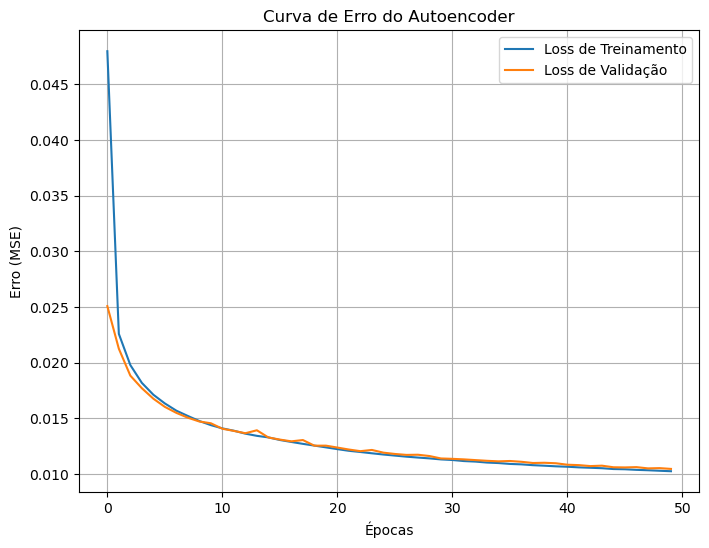

In [4]:
# Plota a curva de erro (loss)
plt.figure(figsize=(8, 6))
plt.plot(history.history["loss"], label="Loss de Treinamento")
plt.plot(history.history["val_loss"], label="Loss de Validação")
plt.title("Curva de Erro do Autoencoder")
plt.xlabel("Épocas")
plt.ylabel("Erro (MSE)")
plt.legend()
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


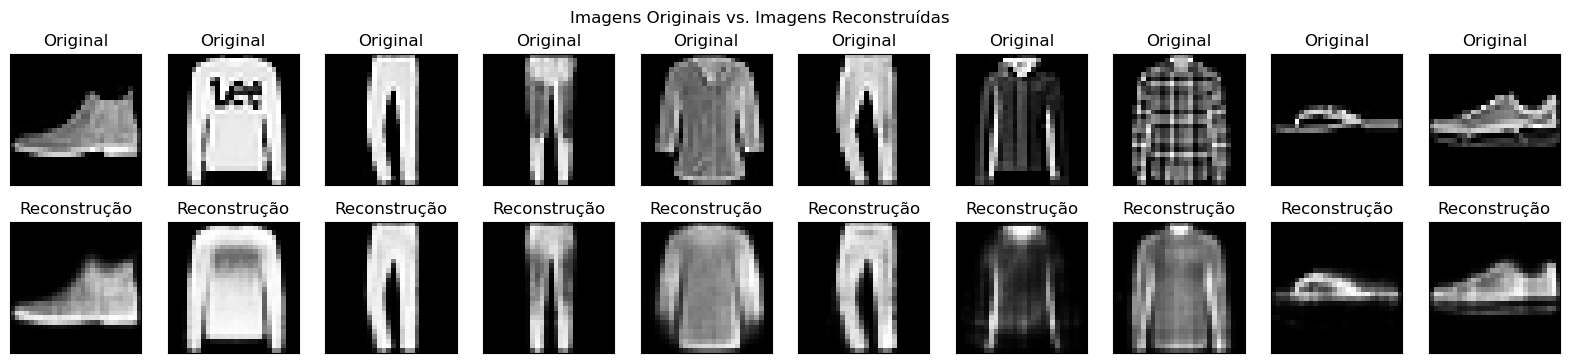

In [5]:
# Gera reconstruções para as 10 primeiras imagens do conjunto de teste
reconstructed_imgs = autoencoder.predict(x_test_flat[:10])

# Visualiza as imagens originais e reconstruídas
n = 10  # Número de imagens a serem exibidas
plt.figure(figsize=(20, 4))
for i in range(n):
    # Exibir imagem original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i])
    plt.title("Original")
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Exibi imagem reconstruída
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed_imgs[i].reshape(28, 28))
    plt.title("Reconstrução")
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.suptitle("Imagens Originais vs. Imagens Reconstruídas")
plt.show()

#### Item b)

Complete o exercício da questão 4(a) adicionando ruído aleatório às imagens de entrada, com o objetivo de treinar um denoising autoencoder.

Após o treinamento, utilize as 10 imagens selecionadas  na  questão  anterior  (com  o  ruído  aplicado)  e  apresente  os  resultados visualmente, exibindo lado a lado as imagens originais e suas respectivas reconstruções.

Avalie qualitativamente o desempenho do modelo em remover o ruído e preservar as características das imagens originais. 

In [6]:
# Adiciona ruído aleatório
noise_factor = 0.5
x_train_noisy = x_train_flat + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_train_flat.shape
)
x_test_noisy = x_test_flat + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_test_flat.shape
)

# Garante que os valores permaneçam no intervalo [0, 1]
x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)
x_test_noisy = np.clip(x_test_noisy, 0.0, 1.0)

In [7]:
# Dimensão da representação comprimida
encoding_dim = 32

# Camada de entrada
input_ = Input(shape=(784,))

# Encoder
encoded = Dense(128, activation="relu")(input_)
encoded = Dense(64, activation="relu")(encoded)
encoded = Dense(encoding_dim, activation="relu")(encoded)

# Decoder
decoded = Dense(64, activation="relu")(encoded)
decoded = Dense(128, activation="relu")(decoded)
decoded = Dense(784, activation="sigmoid")(decoded)

# O modelo Denoising Autoencoder
denoising_autoencoder = Model(input_, decoded)

# Compila o modelo
denoising_autoencoder.compile(optimizer="adam", loss="mean_squared_error")

# Treina o modelo
history = denoising_autoencoder.fit(
    x_train_noisy,
    x_train_flat,
    epochs=50,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_noisy, x_test_flat),
)

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0575 - val_loss: 0.0335
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0290 - val_loss: 0.0271
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0256 - val_loss: 0.0249
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0240 - val_loss: 0.0238
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0228 - val_loss: 0.0225
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0219 - val_loss: 0.0217
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0213 - val_loss: 0.0214
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0209 - val_loss: 0.0209
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0205 - val_loss: 0.0213
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0202 - val_loss: 0.0211
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0199 - val_loss: 0.0204
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step

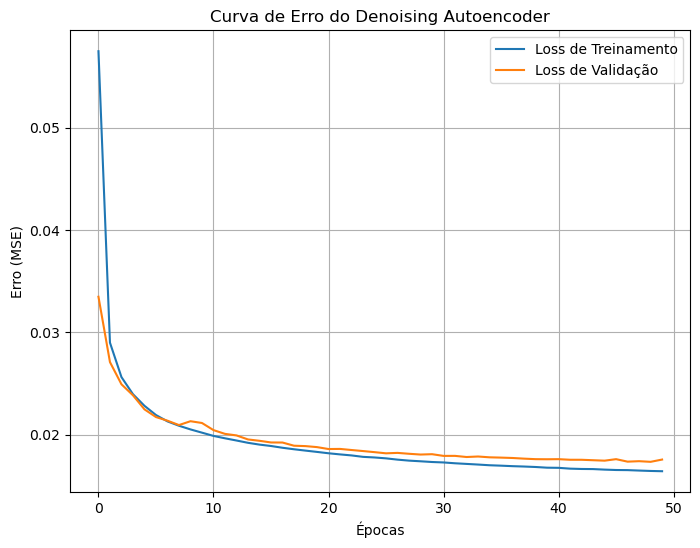

In [8]:
plt.figure(figsize=(8, 6))
plt.plot(history.history["loss"], label="Loss de Treinamento")
plt.plot(history.history["val_loss"], label="Loss de Validação")
plt.title("Curva de Erro do Denoising Autoencoder")
plt.xlabel("Épocas")
plt.ylabel("Erro (MSE)")
plt.legend()
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


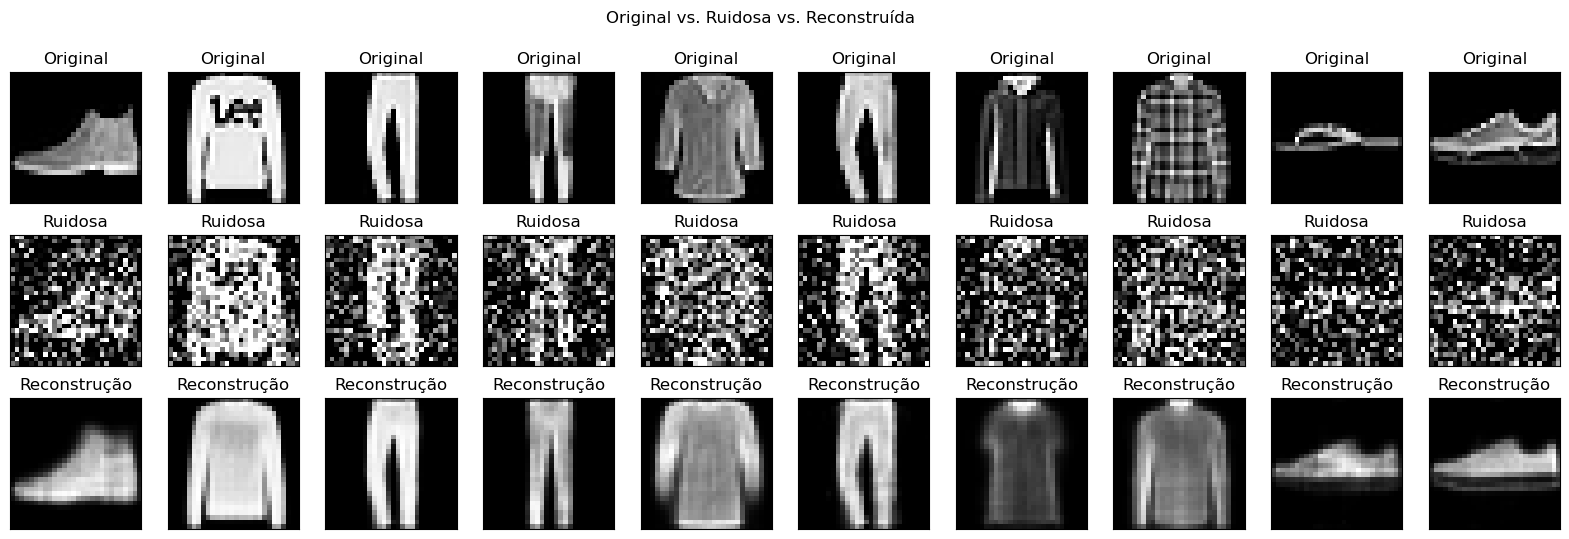

In [9]:
# Gera reconstruções para as 10 primeiras imagens do conjunto de teste com ruído
reconstructed_imgs = denoising_autoencoder.predict(x_test_noisy[:10])

# Visualiza as imagens originais, ruidosas e reconstruídas
n = 10  # Número de imagens
plt.figure(figsize=(20, 6))
for i in range(n):
    # Exibi imagem original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i])
    plt.title("Original")
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Exibi imagem ruidosa
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    plt.title("Ruidosa")
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Exibi imagem reconstruída (sem ruído)
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(reconstructed_imgs[i].reshape(28, 28))
    plt.title("Reconstrução")
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.suptitle("Original vs. Ruidosa vs. Reconstruída")
plt.show()